# OD-16 ML-Baseline: EdgeBoxes + HOG + LinearSVM (Improved)

Pipeline này là **ML-Baseline** dùng để **so sánh với YOLOv8**.

Cải tiến so với bản gốc:
- **Feature phong phú hơn**: HOG + histogram màu HSV (kết hợp)
- **Hard-negative mining**: huấn luyện lại với false-positive để giảm FP
- **Calibrated SVM**: dùng `CalibratedClassifierCV` để có xác suất thực → NMS tốt hơn
- **Đánh giá đầy đủ**: IoU distribution, Precision-Recall curve, mAP@0.5, mAP@0.5:0.95


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 1) Cài thư viện
# opencv-contrib: ximgproc (EdgeBoxes + Structured Edge Detection)
!pip -q install --upgrade opencv-contrib-python scikit-learn pyyaml tqdm pandas matplotlib


In [3]:
!pip install roboflow
from roboflow import Roboflow

rf = Roboflow(api_key="yxnAkYapujcEsCKPsnV1")  # lấy trong Roboflow Settings
project = rf.workspace("prism-ratly").project("prismmm")
version = project.version(1)
dataset = version.download("yolov8")  # sẽ tự tải + unzip


loading Roboflow workspace...
loading Roboflow project...


In [4]:
# 2) Imports
import os, glob, random, time
import numpy as np
import cv2
import yaml
import pandas as pd
from tqdm import tqdm
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.calibration import CalibratedClassifierCV
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

MODEL_PATH = '/content/model.yml.gz'
if not os.path.exists(MODEL_PATH):
    !wget -q -O /content/model.yml.gz https://github.com/opencv/opencv_extra/raw/master/testdata/cv/ximgproc/model.yml.gz

assert hasattr(cv2, 'ximgproc'), 'OpenCV thiếu ximgproc. Hãy cài opencv-contrib-python.'
print('OpenCV:', cv2.__version__)


OpenCV: 4.13.0


In [5]:
# 3) Cấu hình dataset YOLO
# DATA_YAML là file data.yaml của Roboflow export (có train/val/test + names)

DATA_YAML = '/content/prismmm-1/data.yaml'  # <-- sửa đúng đường dẫn của bạn

with open(DATA_YAML, 'r') as f:
    data_cfg = yaml.safe_load(f)

def _normalize_split_path(p, base_dir):
    if p is None:
        return None
    if isinstance(p, str):
        if not os.path.isabs(p):
            parts = p.split(os.sep)
            if parts and parts[0] == '..':
                p_corrected = os.path.join(*parts[1:])
            else:
                p_corrected = p
            return os.path.join(base_dir, p_corrected)
    return p

base_dir    = os.path.dirname(os.path.abspath(DATA_YAML))
train_path  = _normalize_split_path(data_cfg.get('train'), base_dir)
val_path    = _normalize_split_path(data_cfg.get('val'),   base_dir)
test_path   = _normalize_split_path(data_cfg.get('test'),  base_dir)

names = data_cfg.get('names', None)
if isinstance(names, dict):
    names = [names[i] for i in sorted(names.keys())]
if not isinstance(names, list) or len(names) == 0:
    raise ValueError('data.yaml không có names hợp lệ.')

def list_images(path_like):
    if path_like is None:
        return []
    if isinstance(path_like, str) and path_like.endswith('.txt') and os.path.exists(path_like):
        with open(path_like) as f:
            return [ln.strip() for ln in f if ln.strip()]
    if os.path.isdir(path_like):
        imgs = []
        for e in ('*.jpg','*.jpeg','*.png','*.bmp','*.webp'):
            imgs += glob.glob(os.path.join(path_like, e))
        return sorted(imgs)
    return sorted(glob.glob(path_like))

train_images = list_images(train_path)
val_images   = list_images(val_path)
test_images  = list_images(test_path)

print('Classes :', len(names), names)
print('Train/Val/Test:', len(train_images), len(val_images), len(test_images))
if len(train_images) == 0 or len(test_images) == 0:
    raise ValueError('Không tìm thấy ảnh train/test từ data.yaml.')


Classes : 7 ['Backpack', 'Book', 'Bottle', 'Cup', 'Laptop', 'Phone', 'Wallet']
Train/Val/Test: 3665 488 189


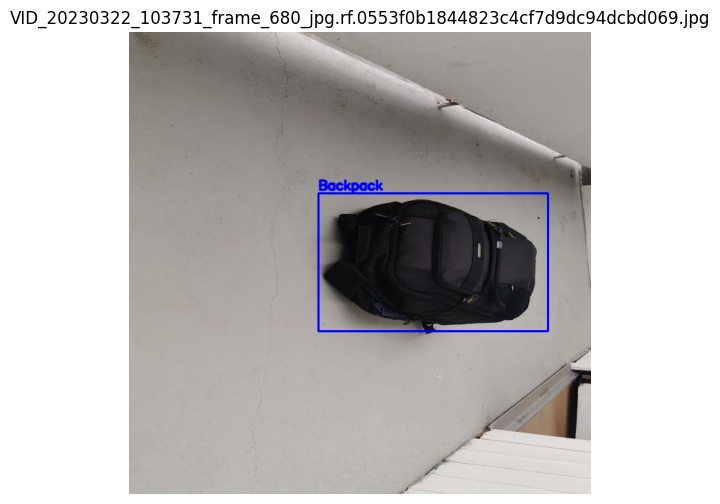

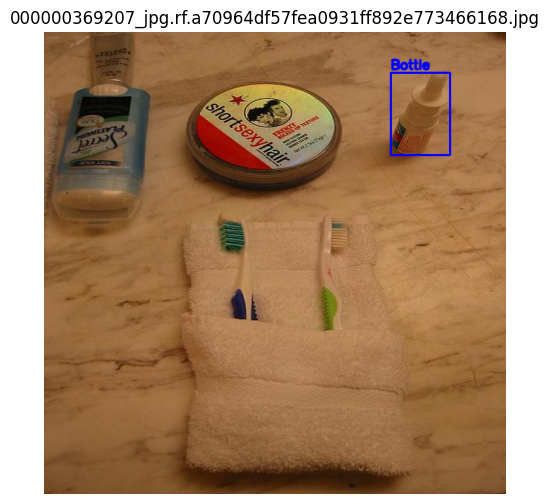

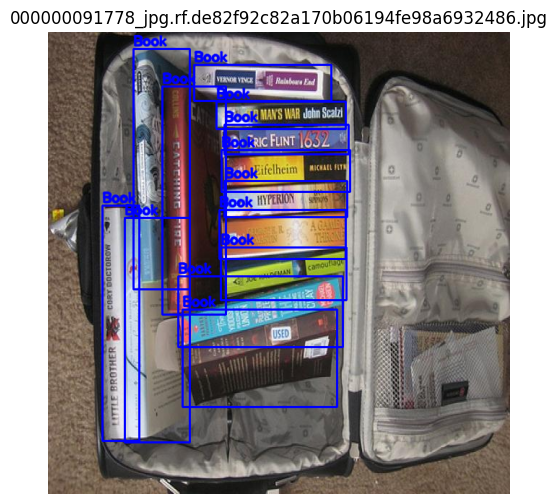

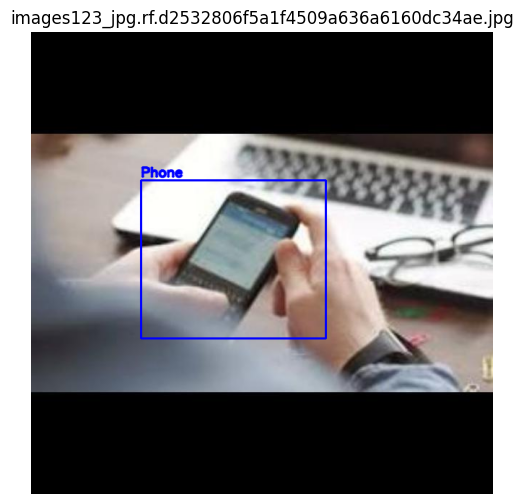

In [6]:
# 4) Utilities: YOLO label, IoU, NMS, draw, sanity-check

def load_yolo_labels(img_path):
    lbl = img_path.replace('/images/', '/labels/')
    lbl = os.path.splitext(lbl)[0] + '.txt'
    out = []
    if not os.path.exists(lbl):
        return out
    with open(lbl) as f:
        for ln in f:
            p = ln.strip().split()
            if len(p) != 5: continue
            c = int(float(p[0]))
            xc,yc,bw,bh = map(float, p[1:])
            out.append((c,xc,yc,bw,bh))
    return out

def yolo_to_xyxy(lbl, w, h):
    c,xc,yc,bw,bh = lbl
    x1 = int(round((xc-bw/2)*w)); y1 = int(round((yc-bh/2)*h))
    x2 = int(round((xc+bw/2)*w)); y2 = int(round((yc+bh/2)*h))
    return x1,y1,x2,y2

def clip_xyxy(x1,y1,x2,y2,w,h):
    x1,y1 = max(0,int(x1)), max(0,int(y1))
    x2,y2 = min(w-1,int(x2)), min(h-1,int(y2))
    return None if x2<=x1 or y2<=y1 else (x1,y1,x2,y2)

def iou_xyxy(a, b):
    ax1,ay1,ax2,ay2 = a; bx1,by1,bx2,by2 = b
    iw = max(0, min(ax2,bx2)-max(ax1,bx1))
    ih = max(0, min(ay2,by2)-max(ay1,by1))
    inter = iw*ih
    if inter <= 0: return 0.0
    ua = (ax2-ax1)*(ay2-ay1) + (bx2-bx1)*(by2-by1) - inter
    return float(inter)/(float(ua)+1e-9)

def nms_xyxy(boxes, scores, score_th=0.0, iou_th=0.5):
    if len(boxes) == 0: return []
    b = [[int(x1),int(y1),int(x2-x1),int(y2-y1)] for (x1,y1,x2,y2) in boxes]
    idxs = cv2.dnn.NMSBoxes(b, list(map(float,scores)),
                             float(score_th), float(iou_th))
    return [] if len(idxs)==0 else idxs.flatten().tolist()

def draw_boxes(img_bgr, boxes, labels=None, color=(0,255,0)):
    out = img_bgr.copy()
    for i,b in enumerate(boxes):
        x1,y1,x2,y2 = b
        cv2.rectangle(out,(x1,y1),(x2,y2),color,2)
        if labels:
            cv2.putText(out,labels[i],(x1,max(0,y1-5)),
                        cv2.FONT_HERSHEY_SIMPLEX,0.6,color,2,cv2.LINE_AA)
    return out

def show_gt_examples(image_paths, k=4):
    for p in random.sample(image_paths, min(k,len(image_paths))):
        img = cv2.imread(p)
        if img is None: continue
        h,w = img.shape[:2]
        boxes, lbls = [], []
        for lb in load_yolo_labels(p):
            b = clip_xyxy(*yolo_to_xyxy(lb,w,h),w,h)
            if b: boxes.append(b); lbls.append(names[int(lb[0])])
        vis = draw_boxes(img, boxes, lbls, color=(255,0,0))
        plt.figure(figsize=(10,6))
        plt.imshow(cv2.cvtColor(vis,cv2.COLOR_BGR2RGB))
        plt.axis('off'); plt.title(os.path.basename(p)); plt.show()

show_gt_examples(train_images, k=4)


In [7]:
# 5) EdgeBoxes proposals (Structured Edge Detection)
def edgeboxes_proposals(img_bgr, max_boxes=300, alpha=0.65, beta=0.75):
    """Return (boxes_xyxy, scores). alpha/beta tuned for higher recall."""
    sed = cv2.ximgproc.createStructuredEdgeDetection(MODEL_PATH)
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
    edges = sed.detectEdges(rgb)
    orimap = sed.computeOrientation(edges)
    edges_nms = sed.edgesNms(edges, orimap)

    eb = cv2.ximgproc.createEdgeBoxes()
    eb.setMaxBoxes(int(max_boxes))
    eb.setAlpha(float(alpha))
    eb.setBeta(float(beta))
    eb.setMinScore(0.01)  # lower threshold → more recall

    boxes, scores = eb.getBoundingBoxes(edges_nms, orimap)  # (x,y,w,h)
    h, w = img_bgr.shape[:2]
    out_b, out_s = [], []
    for (x,y,bw,bh), sc in zip(boxes, scores):
        c = clip_xyxy(x,y,x+bw,y+bh,w,h)
        if c: out_b.append(c); out_s.append(float(sc))
    return out_b, out_s


In [8]:
# 6) Improved feature extraction: HOG + HSV colour histogram
#    Concatenating appearance (colour) with shape (HOG) gives richer descriptors
#    than HOG alone → better SVM discrimination.

IMG_SIZE = 128  # patch resize target

def hog_features(patch_bgr, win=IMG_SIZE):
    patch = cv2.resize(patch_bgr,(win,win),interpolation=cv2.INTER_AREA)
    gray  = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
    hog   = cv2.HOGDescriptor(
        _winSize=(win,win), _blockSize=(win//2,win//2),
        _blockStride=(win//4,win//4), _cellSize=(win//4,win//4), _nbins=9)
    return hog.compute(gray).reshape(-1).astype(np.float32)

def color_hist_features(patch_bgr, bins=32):
    """HSV colour histogram (bins per channel), L2-normalised."""
    patch = cv2.resize(patch_bgr,(64,64),interpolation=cv2.INTER_AREA)
    hsv   = cv2.cvtColor(patch, cv2.COLOR_BGR2HSV)
    hists = []
    for ch in range(3):
        h = cv2.calcHist([hsv],[ch],None,[bins],[0,256]).flatten()
        hists.append(h)
    feat = np.concatenate(hists).astype(np.float32)
    norm = np.linalg.norm(feat)
    return feat / (norm + 1e-9)

def extract_features(patch_bgr):
    """Concatenate HOG + colour histogram."""
    return np.concatenate([hog_features(patch_bgr), color_hist_features(patch_bgr)])

# Quick dim check
dummy = np.zeros((64,64,3), dtype=np.uint8)
print('Feature dim:', extract_features(dummy).shape[0])


Feature dim: 420


In [9]:
# 7) Build initial training samples (proposals → IoU thresholding → feature)
!pip install opencv-contrib-python-headless
POS_IOU = 0.5
NEG_IOU = 0.3   # raised from 0.2 → cleaner negatives

MAX_PROPOSALS_PER_IMG = 400  # more proposals → better recall
MAX_POS_PER_GT  = 20
MAX_NEG_PER_IMG = 60
LIMIT_TRAIN_IMAGES = 800

def build_train_samples(image_paths, max_images=LIMIT_TRAIN_IMAGES):
    X, y = [], []
    for img_path in tqdm(image_paths[:max_images]):
        img = cv2.imread(img_path)
        if img is None: continue
        h,w = img.shape[:2]

        gts, gt_cls = [], []
        for lb in load_yolo_labels(img_path):
            b = clip_xyxy(*yolo_to_xyxy(lb,w,h),w,h)
            if b: gts.append(b); gt_cls.append(int(lb[0]))

        prop_boxes, _ = edgeboxes_proposals(img, max_boxes=MAX_PROPOSALS_PER_IMG)

        pos_by_gt = [[] for _ in gts]
        neg_boxes = []
        for pb in prop_boxes:
            best_iou, best_j = 0.0, -1
            for j,gt in enumerate(gts):
                v = iou_xyxy(pb,gt)
                if v > best_iou: best_iou,best_j = v,j
            if best_iou >= POS_IOU and best_j >= 0:
                pos_by_gt[best_j].append(pb)
            elif best_iou <= NEG_IOU:
                neg_boxes.append(pb)

        for j,pbs in enumerate(pos_by_gt):
            random.shuffle(pbs)
            for pb in pbs[:MAX_POS_PER_GT]:
                x1,y1,x2,y2 = pb
                patch = img[y1:y2,x1:x2]
                if patch.size == 0: continue
                X.append(extract_features(patch)); y.append(gt_cls[j])

        random.shuffle(neg_boxes)
        for pb in neg_boxes[:MAX_NEG_PER_IMG]:
            x1,y1,x2,y2 = pb
            patch = img[y1:y2,x1:x2]
            if patch.size == 0: continue
            X.append(extract_features(patch)); y.append(-1)

    if len(X) == 0:
        raise ValueError('Không tạo được sample train.')
    return np.stack(X), np.array(y, dtype=np.int32)

Xtr, ytr = build_train_samples(train_images)
print('Train samples:', Xtr.shape)
print('Label counts:', pd.Series(ytr).value_counts().to_dict())

100%|██████████| 800/800 [29:39<00:00,  2.22s/it]


Train samples: (61753, 420)
Label counts: {-1: 48000, 4: 6636, 1: 2439, 0: 1657, 5: 1392, 3: 1048, 2: 472, 6: 109}


In [10]:
# 8) Train initial multi-class SVM
#    CalibratedClassifierCV wraps LinearSVC to produce reliable probabilities
#    → confidence scores used in NMS are more meaningful than raw margins.

from sklearn.calibration import CalibratedClassifierCV

def make_clf():
    base = LinearSVC(C=0.5, class_weight='balanced', max_iter=8000, dual=False)
    cal  = CalibratedClassifierCV(base, cv=3, method='sigmoid')
    return make_pipeline(StandardScaler(), cal)

clf = make_clf()
clf.fit(Xtr, ytr)
print('Classes:', clf.named_steps['calibratedclassifiercv'].classes_)


Classes: [-1  0  1  2  3  4  5  6]


In [11]:
# 9) Hard-negative mining (1 round)
#    Run detector on TRAIN images → collect false-positive proposals (model
#    predicts non-background but IoU with any GT < 0.3).  Retrain with these
#    hard negatives mixed in → large reduction in false positives at test time.

CONF_TH_MINE = 0.5   # confidence threshold for mining candidates
MAX_HN_PER_IMG = 30  # cap hard-negatives per image to avoid imbalance
LIMIT_MINE_IMAGES = 300

def infer_proposals(img_bgr, max_boxes=MAX_PROPOSALS_PER_IMG):
    """Return class-predictions (no background) and boxes with probability scores."""
    prop_boxes, _ = edgeboxes_proposals(img_bgr, max_boxes=max_boxes)
    if len(prop_boxes) == 0:
        return []
    feats = []
    valid = []
    for b in prop_boxes:
        x1,y1,x2,y2 = b
        patch = img_bgr[y1:y2,x1:x2]
        if patch.size == 0: continue
        feats.append(extract_features(patch)); valid.append(b)
    if len(feats) == 0:
        return []
    F = np.stack(feats)
    probs  = clf.predict_proba(F)          # (N, n_classes)
    classes = clf.named_steps['calibratedclassifiercv'].classes_
    best_idx   = np.argmax(probs, axis=1)
    best_cls   = classes[best_idx]
    best_score = probs[np.arange(len(probs)), best_idx]
    return list(zip(best_cls.tolist(), best_score.tolist(), valid))

print('Mining hard negatives …')
Xhn, yhn = [], []
mine_paths = train_images[:LIMIT_MINE_IMAGES]
for img_path in tqdm(mine_paths):
    img = cv2.imread(img_path)
    if img is None: continue
    h,w = img.shape[:2]
    gts = []
    for lb in load_yolo_labels(img_path):
        b = clip_xyxy(*yolo_to_xyxy(lb,w,h),w,h)
        if b: gts.append(b)
    dets = infer_proposals(img)
    hn_count = 0
    for (c, s, b) in dets:
        if int(c) == -1 or float(s) < CONF_TH_MINE:
            continue
        best_iou = max((iou_xyxy(b,gt) for gt in gts), default=0.0)
        if best_iou < 0.3:   # false positive → hard negative
            x1,y1,x2,y2 = b
            patch = img[y1:y2,x1:x2]
            if patch.size == 0: continue
            Xhn.append(extract_features(patch)); yhn.append(-1)
            hn_count += 1
            if hn_count >= MAX_HN_PER_IMG:
                break

if len(Xhn) > 0:
    Xhn = np.stack(Xhn); yhn = np.array(yhn, dtype=np.int32)
    Xtr2 = np.vstack([Xtr, Xhn])
    ytr2 = np.concatenate([ytr, yhn])
    print(f'Hard negatives collected: {len(yhn)}')
    print('Retraining with hard negatives …')
    clf = make_clf()
    clf.fit(Xtr2, ytr2)
    print('Retraining done.')
else:
    print('No hard negatives found – keeping original model.')


Mining hard negatives …


100%|██████████| 300/300 [14:03<00:00,  2.81s/it]


Hard negatives collected: 84
Retraining with hard negatives …
Retraining done.


In [12]:
# 10) Inference: proposals → feature → calibrated SVM → NMS

CONF_TH = 0.4   # min class probability to keep a detection
NMS_IOU = 0.45  # NMS overlap threshold

def infer_one(img_bgr):
    prop_boxes, _ = edgeboxes_proposals(img_bgr, max_boxes=MAX_PROPOSALS_PER_IMG)
    feats, boxes = [], []
    for b in prop_boxes:
        x1,y1,x2,y2 = b
        patch = img_bgr[y1:y2,x1:x2]
        if patch.size == 0: continue
        feats.append(extract_features(patch)); boxes.append(b)
    if len(boxes) == 0:
        return []

    F      = np.stack(feats)
    probs  = clf.predict_proba(F)          # (N, n_classes)
    classes = clf.named_steps['calibratedclassifiercv'].classes_
    best_idx   = np.argmax(probs, axis=1)
    best_cls   = classes[best_idx]
    best_score = probs[np.arange(len(probs)), best_idx]

    dets = [(int(c), float(s), b)
            for c,s,b in zip(best_cls, best_score, boxes)
            if int(c) != -1 and float(s) >= CONF_TH]

    out = []
    for c in range(len(names)):
        cb = [b for (cc,s,b) in dets if cc==c]
        cs = [s for (cc,s,b) in dets if cc==c]
        if not cb: continue
        keep = nms_xyxy(cb, cs, score_th=CONF_TH, iou_th=NMS_IOU)
        for k in keep:
            out.append((c, cs[k], cb[k]))
    out.sort(key=lambda x: x[1], reverse=True)
    return out


In [13]:
# 11) Evaluation helpers: AP / mAP@thresh, PR curve data

def compute_ap(preds, gts_by_img, iou_th=0.5):
    """11-point interpolated AP (PASCAL VOC style)."""
    preds = sorted(preds, key=lambda x: x[1], reverse=True)
    total_gt = sum(len(v) for v in gts_by_img.values())
    if total_gt == 0:
        return None, None, None

    gt_used = {img_id: [False]*len(gts_by_img[img_id])
               for img_id in gts_by_img}
    tp = np.zeros(len(preds), np.float32)
    fp = np.zeros(len(preds), np.float32)

    for i,(img_id, score, box) in enumerate(preds):
        gts = gts_by_img.get(img_id, [])
        best_iou, best_j = 0.0, -1
        for j,gt in enumerate(gts):
            if gt_used[img_id][j]: continue
            v = iou_xyxy(box, gt)
            if v > best_iou: best_iou,best_j = v,j
        if best_iou >= iou_th and best_j >= 0:
            tp[i] = 1; gt_used[img_id][best_j] = True
        else:
            fp[i] = 1

    tp_c = np.cumsum(tp); fp_c = np.cumsum(fp)
    rec  = tp_c / (total_gt + 1e-9)
    prec = tp_c / (tp_c + fp_c + 1e-9)

    mrec = np.concatenate(([0.],rec,[1.]))
    mpre = np.concatenate(([0.],prec,[0.]))
    for i in range(len(mpre)-2,-1,-1):
        mpre[i] = max(mpre[i],mpre[i+1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap  = float(np.sum((mrec[idx+1]-mrec[idx])*mpre[idx+1]))
    return ap, rec, prec

def evaluate_split(image_paths, max_images=None, iou_th=0.5):
    valid = [p for p in (image_paths[:max_images] if max_images else image_paths)
             if cv2.imread(p) is not None]

    gts   = {c:{} for c in range(len(names))}
    for img_id,p in enumerate(valid):
        img = cv2.imread(p); h,w = img.shape[:2]
        for lb in load_yolo_labels(p):
            c = int(lb[0])
            b = clip_xyxy(*yolo_to_xyxy(lb,w,h),w,h)
            if b: gts[c].setdefault(img_id,[]).append(b)

    preds = {c:[] for c in range(len(names))}
    tp    = {c:0 for c in range(len(names))}
    fp    = {c:0 for c in range(len(names))}
    fn    = {c:0 for c in range(len(names))}
    total_time = 0.0

    for img_id,p in enumerate(tqdm(valid)):
        img = cv2.imread(p)
        t0  = time.time()
        dets = infer_one(img)
        total_time += time.time()-t0

        for c,s,b in dets:
            preds[c].append((img_id,s,b))

        for c in range(len(names)):
            gt_boxes  = gts[c].get(img_id,[])
            det_boxes = [b for (cc,s,b) in dets if cc==c]
            det_scores= [s for (cc,s,b) in dets if cc==c]
            matched   = [False]*len(gt_boxes)
            order = np.argsort(-np.array(det_scores)) if det_scores else []
            for k in order:
                b = det_boxes[int(k)]
                best_iou, best_j = 0.0,-1
                for j,gb in enumerate(gt_boxes):
                    if matched[j]: continue
                    v = iou_xyxy(b,gb)
                    if v > best_iou: best_iou,best_j = v,j
                if best_iou >= iou_th and best_j >= 0:
                    tp[c]+=1; matched[best_j]=True
                else:
                    fp[c]+=1
            fn[c] += matched.count(False)

    rows, ap_list, pr_data = [], [], {}
    for c in range(len(names)):
        ap, rec_arr, prec_arr = compute_ap(preds[c], gts[c], iou_th)
        if ap is not None: ap_list.append(ap)
        pr_data[c] = (rec_arr, prec_arr)
        P  = tp[c]/(tp[c]+fp[c]+1e-9)
        R  = tp[c]/(tp[c]+fn[c]+1e-9)
        F1 = 2*P*R/(P+R+1e-9)
        rows.append([names[c], ap, P, R, F1, tp[c], fp[c], fn[c]])

    mAP  = float(np.mean(ap_list)) if ap_list else None
    lat  = total_time/max(len(valid),1)
    fps  = (1./lat) if lat>0 else None
    df   = pd.DataFrame(rows, columns=['class','AP@0.5','Precision','Recall','F1','TP','FP','FN'])
    return df, mAP, lat, fps, pr_data


In [14]:
# 12) mAP@0.5:0.95 (COCO-style): average AP over IoU in [0.50, 0.55, …, 0.95]

def compute_map_coco(image_paths, max_images=None):
    iou_thresholds = np.arange(0.50, 1.00, 0.05)  # 0.50 … 0.95
    valid = [p for p in (image_paths[:max_images] if max_images else image_paths)
             if cv2.imread(p) is not None]

    # Collect all predictions once
    gts_all   = {c:{} for c in range(len(names))}
    preds_all = {c:[] for c in range(len(names))}
    for img_id,p in enumerate(tqdm(valid, desc='Inference for mAP COCO')):
        img = cv2.imread(p); h,w = img.shape[:2]
        for lb in load_yolo_labels(p):
            c = int(lb[0])
            b = clip_xyxy(*yolo_to_xyxy(lb,w,h),w,h)
            if b: gts_all[c].setdefault(img_id,[]).append(b)
        for c,s,b in infer_one(img):
            preds_all[c].append((img_id,s,b))

    ap_matrix = []  # shape (n_classes_with_gt, n_thresholds)
    for iou_th in iou_thresholds:
        ap_row = []
        for c in range(len(names)):
            ap,_,_ = compute_ap(preds_all[c], gts_all[c], iou_th=iou_th)
            if ap is not None: ap_row.append(ap)
        ap_matrix.append(np.mean(ap_row) if ap_row else 0.0)

    return float(np.mean(ap_matrix)), iou_thresholds, ap_matrix


In [15]:
# 13) Run evaluation on TEST set

df_eval, mAP50, latency, fps, pr_data = evaluate_split(test_images, iou_th=0.5)

print('\n' + '='*60)
print('  ĐÁNH GIÁ TRÊN TẬP TEST – EdgeBoxes + HOG/Colour + SVM')
print('='*60)
print(f'  mAP@0.5          : {mAP50:.4f}')
print(f'  Latency (s/img)  : {latency:.3f}')
print(f'  FPS              : {fps:.1f}')
print('='*60)
df_eval = df_eval.round(4)
print(df_eval.to_string(index=False))


100%|██████████| 189/189 [07:40<00:00,  2.44s/it]


  ĐÁNH GIÁ TRÊN TẬP TEST – EdgeBoxes + HOG/Colour + SVM
  mAP@0.5          : 0.0000
  Latency (s/img)  : 2.431
  FPS              : 0.4
   class  AP@0.5  Precision  Recall  F1  TP  FP  FN
Backpack     0.0        0.0     0.0 0.0   0   0   1
    Book     0.0        0.0     0.0 0.0   0   0  97
  Bottle     0.0        0.0     0.0 0.0   0   0  20
     Cup     0.0        0.0     0.0 0.0   0   0  29
  Laptop     0.0        0.0     0.0 0.0   0 109   3
   Phone     0.0        0.0     0.0 0.0   0   9  88
  Wallet     0.0        0.0     0.0 0.0   0   0  51


Inference for mAP COCO: 100%|██████████| 189/189 [07:40<00:00,  2.44s/it]


mAP@0.5:0.95 = 0.0000


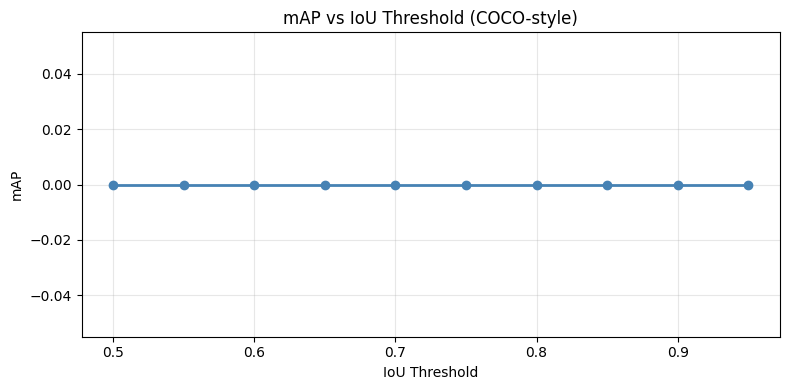

In [16]:
# 14) Compute mAP@0.5:0.95 (COCO-style)
# Note: chạy inference lại trên test set → có thể tốn vài phút

mAP5095, iou_thresholds, ap_per_thresh = compute_map_coco(test_images)
print(f'mAP@0.5:0.95 = {mAP5095:.4f}')

# Plot AP vs IoU threshold
plt.figure(figsize=(8,4))
plt.plot(iou_thresholds, ap_per_thresh, 'o-', color='steelblue', linewidth=2)
plt.xlabel('IoU Threshold')
plt.ylabel('mAP')
plt.title('mAP vs IoU Threshold (COCO-style)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


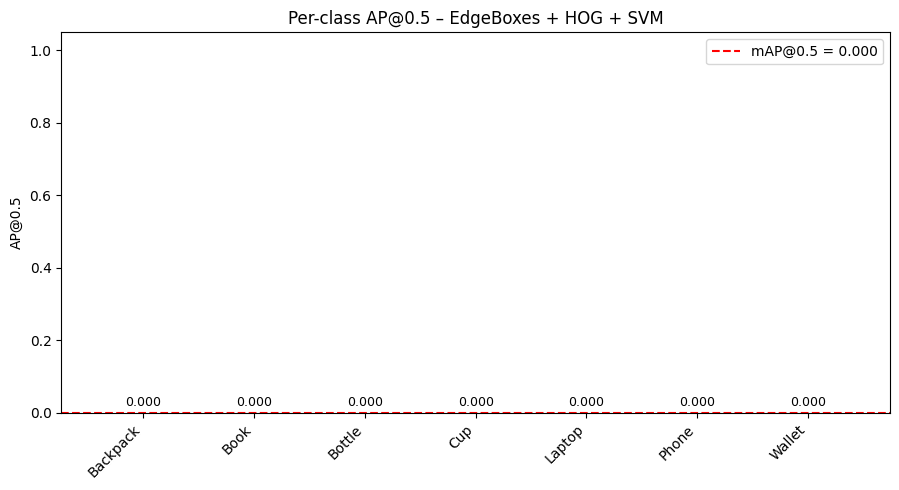

In [17]:
# 15) Per-class AP@0.5 bar chart

fig, ax = plt.subplots(figsize=(max(8, len(names)*1.3), 5))
bars = ax.bar(df_eval['class'], df_eval['AP@0.5'],
              color='steelblue', edgecolor='white')
ax.axhline(mAP50, color='red', linestyle='--', linewidth=1.5,
           label=f'mAP@0.5 = {mAP50:.3f}')
ax.set_ylim(0, 1.05)
ax.set_ylabel('AP@0.5')
ax.set_title('Per-class AP@0.5 – EdgeBoxes + HOG + SVM')
ax.legend()
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.01,
            f'{h:.3f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


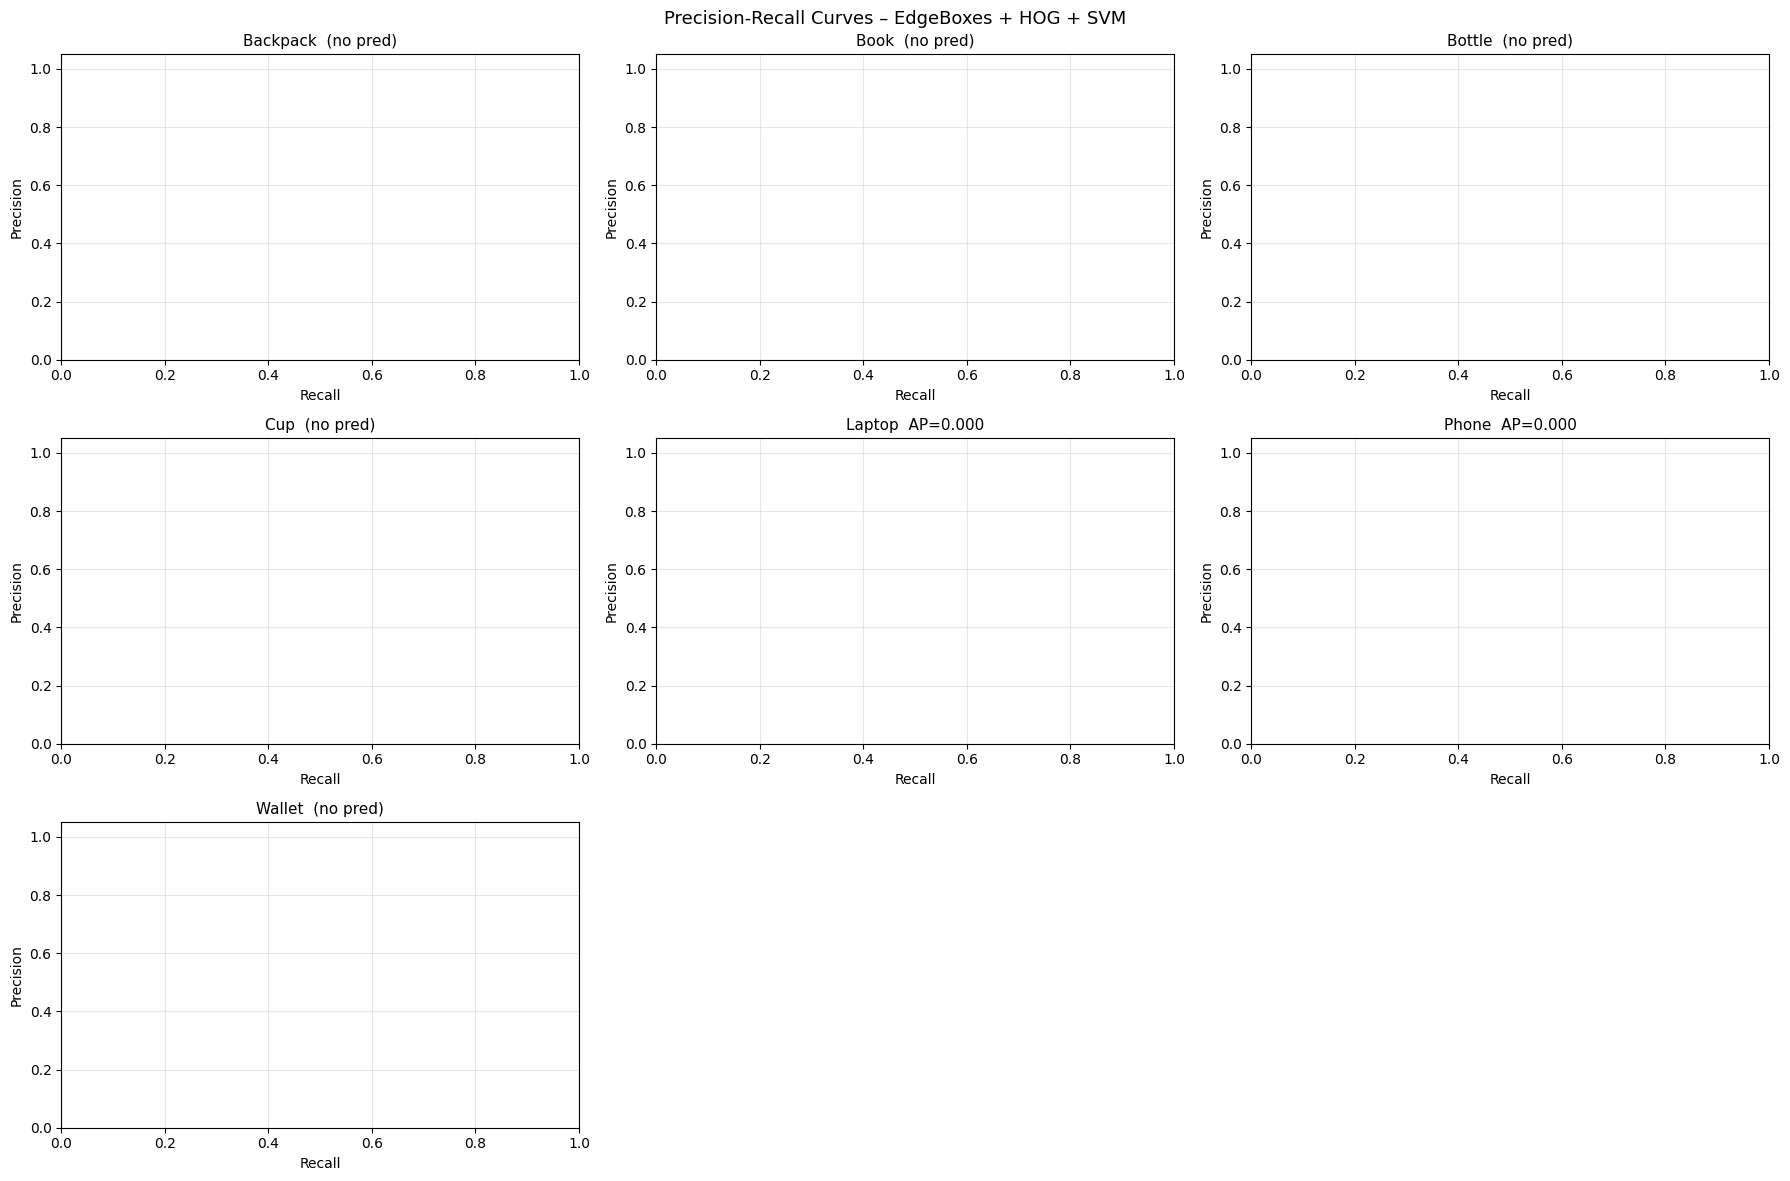

In [18]:
# 16) Precision-Recall curves per class

ncols = min(3, len(names))
nrows = (len(names) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), squeeze=False)

for idx, c in enumerate(range(len(names))):
    ax = axes[idx//ncols][idx%ncols]
    rec_arr, prec_arr = pr_data.get(c, (None, None))
    if rec_arr is not None and len(rec_arr) > 0:
        ap_val = float(df_eval[df_eval['class']==names[c]]['AP@0.5'].values[0])
        ax.plot(rec_arr, prec_arr, linewidth=2, color='steelblue')
        ax.fill_between(rec_arr, prec_arr, alpha=0.2, color='steelblue')
        ax.set_title(f'{names[c]}  AP={ap_val:.3f}', fontsize=11)
    else:
        ax.set_title(f'{names[c]}  (no pred)', fontsize=11)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_xlim(0,1); ax.set_ylim(0,1.05)
    ax.grid(True, alpha=0.3)

# hide unused axes
for idx in range(len(names), nrows*ncols):
    axes[idx//ncols][idx%ncols].set_visible(False)

plt.suptitle('Precision-Recall Curves – EdgeBoxes + HOG + SVM', fontsize=13)
plt.tight_layout()
plt.show()


IoU dist: 100%|██████████| 189/189 [07:39<00:00,  2.43s/it]


Total predictions : 118
Mean IoU          : 0.1916
Median IoU        : 0.1153
IoU >= 0.50 (%)   : 9.3%
IoU >= 0.75 (%)   : 1.7%


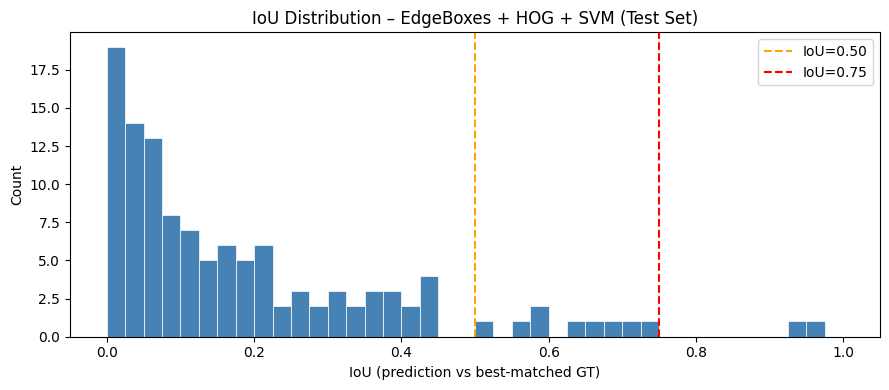

In [19]:
# 17) IoU distribution – histogram of best-matched IoU for each prediction

iou_vals = []
for img_path in tqdm(test_images[:min(200,len(test_images))], desc='IoU dist'):
    img = cv2.imread(img_path)
    if img is None: continue
    h,w = img.shape[:2]
    gt_boxes = [clip_xyxy(*yolo_to_xyxy(lb,w,h),w,h)
                for lb in load_yolo_labels(img_path)]
    gt_boxes = [b for b in gt_boxes if b]
    for c,s,pb in infer_one(img):
        best = max((iou_xyxy(pb,gt) for gt in gt_boxes), default=0.0)
        iou_vals.append(best)

if iou_vals:
    iou_arr = np.array(iou_vals)
    print(f'Total predictions : {len(iou_arr)}')
    print(f'Mean IoU          : {iou_arr.mean():.4f}')
    print(f'Median IoU        : {np.median(iou_arr):.4f}')
    print(f'IoU >= 0.50 (%)   : {(iou_arr>=0.5).mean()*100:.1f}%')
    print(f'IoU >= 0.75 (%)   : {(iou_arr>=0.75).mean()*100:.1f}%')

    plt.figure(figsize=(9,4))
    plt.hist(iou_arr, bins=40, range=(0,1), color='steelblue',
             edgecolor='white', linewidth=0.5)
    plt.axvline(0.50, color='orange', linestyle='--', linewidth=1.5, label='IoU=0.50')
    plt.axvline(0.75, color='red',    linestyle='--', linewidth=1.5, label='IoU=0.75')
    plt.xlabel('IoU (prediction vs best-matched GT)')
    plt.ylabel('Count')
    plt.title('IoU Distribution – EdgeBoxes + HOG + SVM (Test Set)')
    plt.legend()
    plt.tight_layout()
    plt.show()


The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)


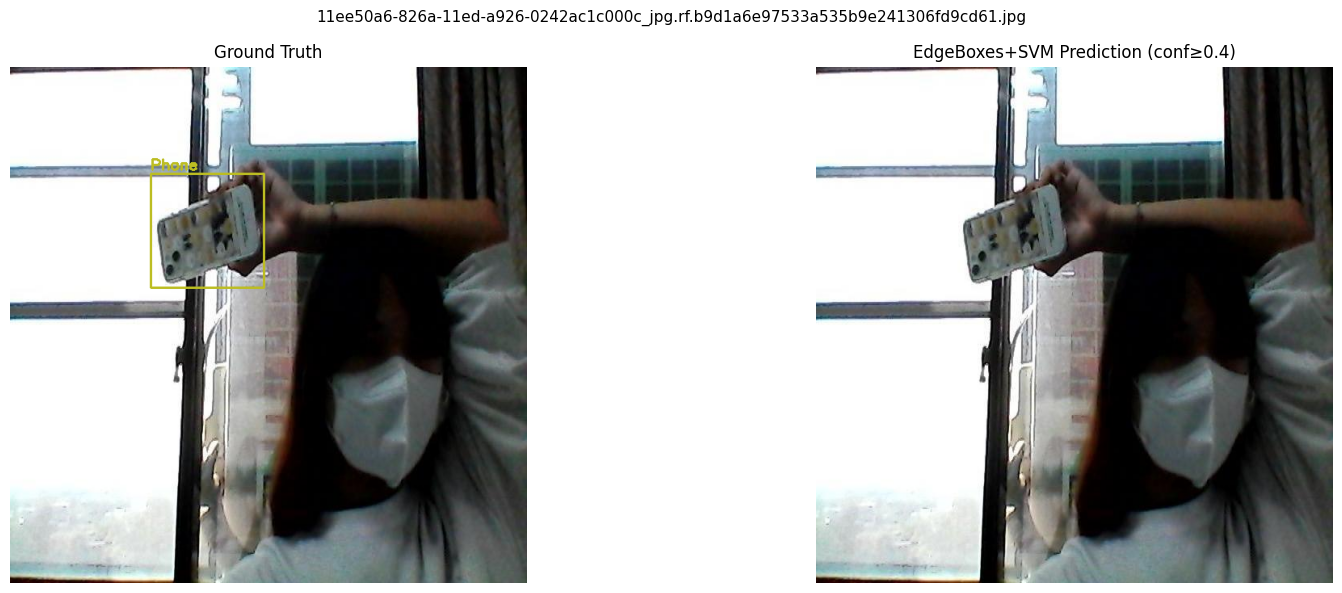

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)


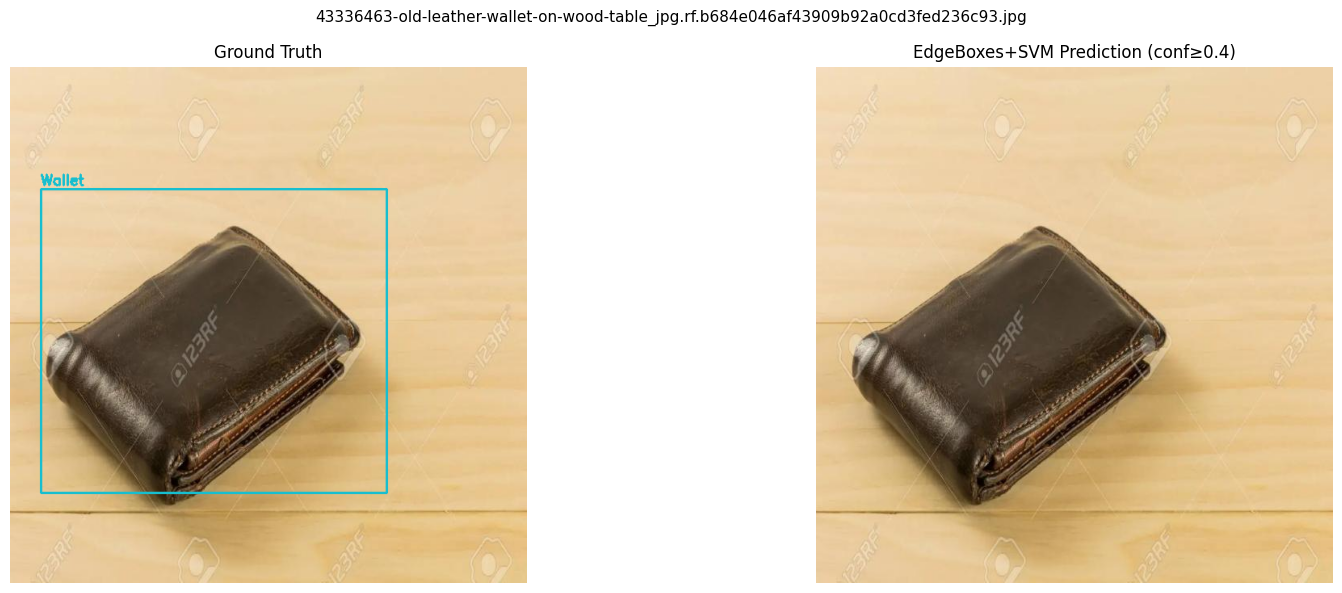

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)


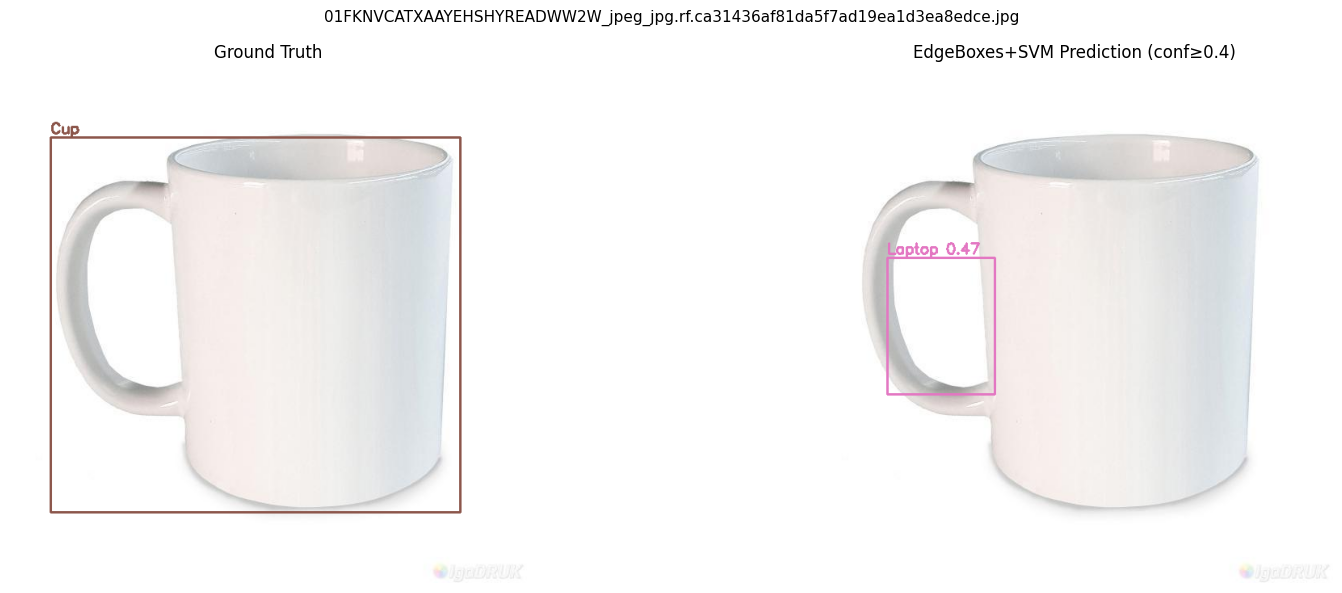

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)


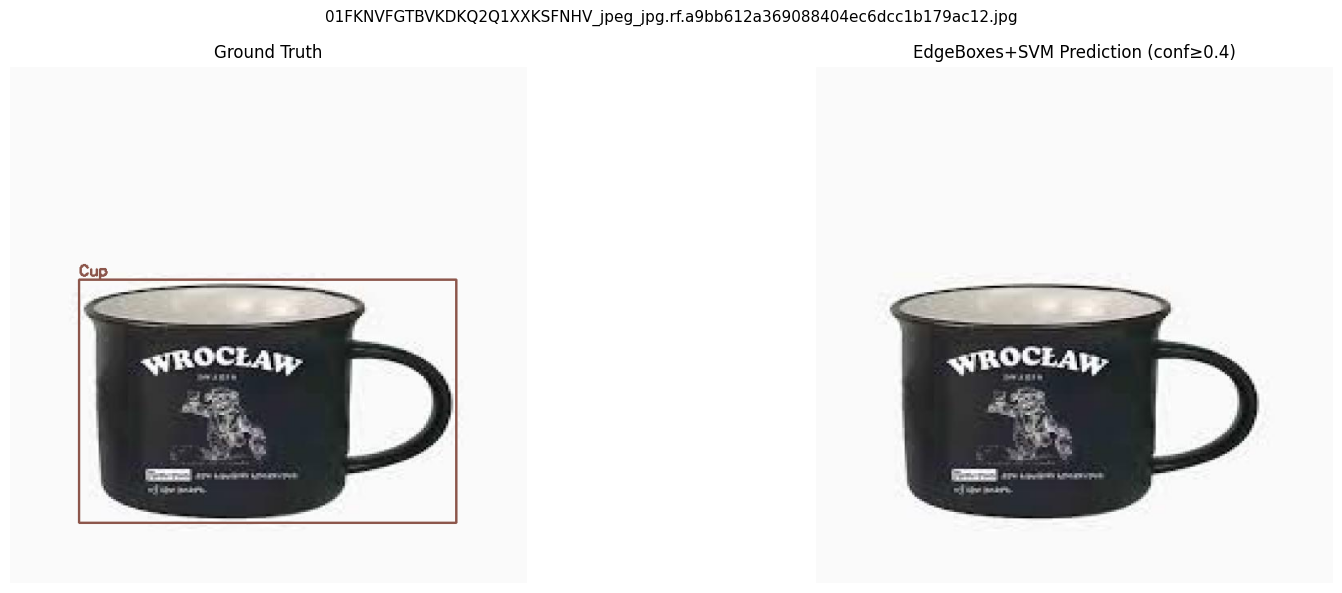

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)


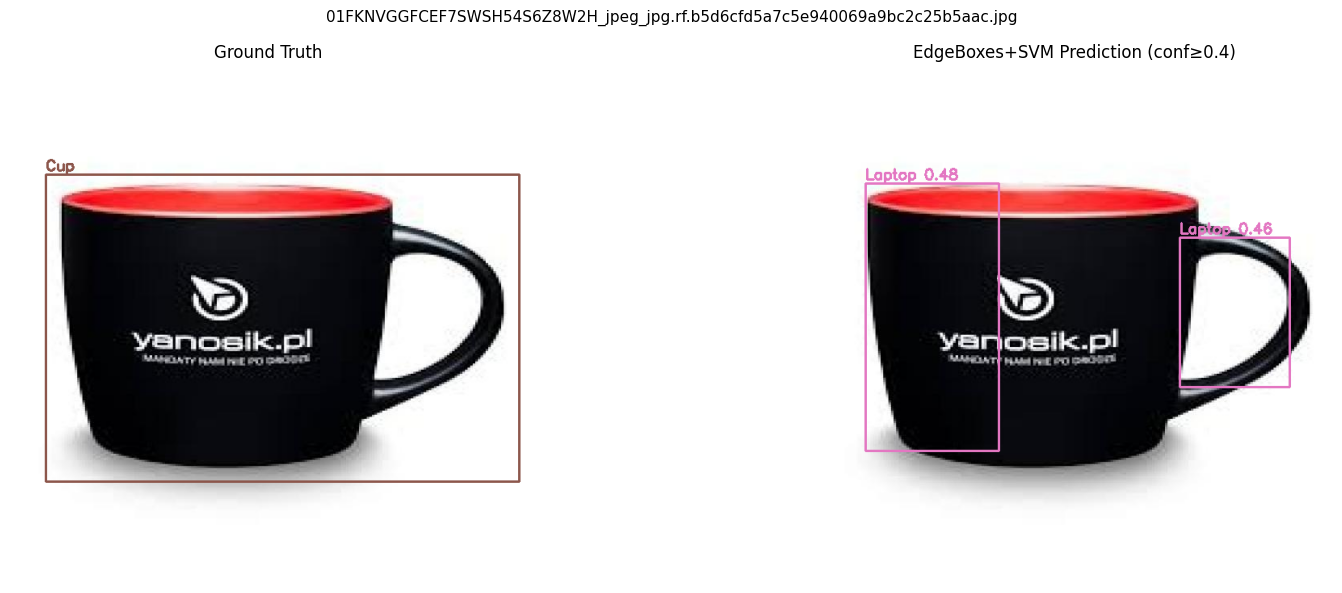

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)


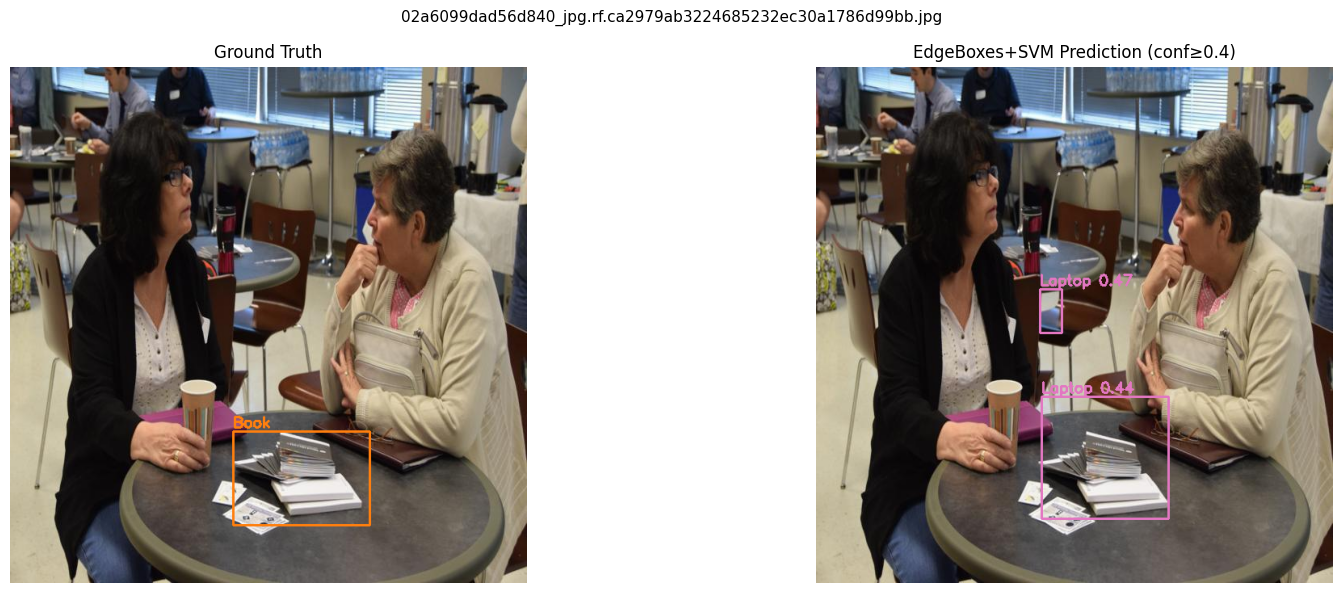

In [20]:
# 18) Visualize: GT vs Prediction on random test images

COLORS = plt.cm.get_cmap('tab10', max(len(names),1))
NUM_SHOW = 6

for img_path in random.sample(test_images, min(NUM_SHOW, len(test_images))):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None: continue
    h,w = img_bgr.shape[:2]

    # Ground-truth
    img_gt = img_bgr.copy()
    for lb in load_yolo_labels(img_path):
        c = int(lb[0])
        b = clip_xyxy(*yolo_to_xyxy(lb,w,h),w,h)
        if b is None: continue
        x1,y1,x2,y2 = b
        rgb = tuple(int(x*255) for x in COLORS(c)[:3])
        bgr = (rgb[2],rgb[1],rgb[0])
        cv2.rectangle(img_gt,(x1,y1),(x2,y2),bgr,2)
        cv2.putText(img_gt,names[c],(x1,max(0,y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX,0.6,bgr,2)

    # Prediction
    img_pred = img_bgr.copy()
    for c,s,b in infer_one(img_bgr):
        x1,y1,x2,y2 = b
        rgb = tuple(int(x*255) for x in COLORS(c)[:3])
        bgr = (rgb[2],rgb[1],rgb[0])
        cv2.rectangle(img_pred,(x1,y1),(x2,y2),bgr,2)
        cv2.putText(img_pred,f'{names[c]} {s:.2f}',(x1,max(0,y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX,0.6,bgr,2)

    fig, axes = plt.subplots(1,2,figsize=(18,6))
    axes[0].imshow(cv2.cvtColor(img_gt,  cv2.COLOR_BGR2RGB))
    axes[0].set_title('Ground Truth'); axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(img_pred,cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'EdgeBoxes+SVM Prediction (conf≥{CONF_TH})')
    axes[1].axis('off')
    plt.suptitle(os.path.basename(img_path), fontsize=11)
    plt.tight_layout()
    plt.show()


In [21]:
# 19) Tóm tắt kết quả cuối cùng

print('='*60)
print('     KẾT QUẢ ĐÁNH GIÁ – EdgeBoxes + HOG/Colour + SVM')
print('='*60)
print(f'  mAP@0.5          : {mAP50:.4f}')
print(f'  mAP@0.5:0.95     : {mAP5095:.4f}')
mean_P  = df_eval['Precision'].mean()
mean_R  = df_eval['Recall'].mean()
mean_F1 = df_eval['F1'].mean()
print(f'  Mean Precision   : {mean_P:.4f}')
print(f'  Mean Recall      : {mean_R:.4f}')
print(f'  Mean F1          : {mean_F1:.4f}')
if iou_vals:
    iou_arr = np.array(iou_vals)
    print(f'  Mean IoU         : {iou_arr.mean():.4f}')
    print(f'  IoU>=0.50 rate   : {(iou_arr>=0.5).mean()*100:.1f}%')
print(f'  Latency (s/img)  : {latency:.3f}')
print(f'  FPS              : {fps:.1f}')
print('='*60)
print('\nPer-class metrics:')
summary = df_eval[['class','AP@0.5','Precision','Recall','F1']].copy()
total_row = pd.DataFrame([['** mean **', mAP50, mean_P, mean_R, mean_F1]],
                          columns=summary.columns)
print(pd.concat([summary, total_row], ignore_index=True).round(4).to_string(index=False))


     KẾT QUẢ ĐÁNH GIÁ – EdgeBoxes + HOG/Colour + SVM
  mAP@0.5          : 0.0000
  mAP@0.5:0.95     : 0.0000
  Mean Precision   : 0.0000
  Mean Recall      : 0.0000
  Mean F1          : 0.0000
  Mean IoU         : 0.1916
  IoU>=0.50 rate   : 9.3%
  Latency (s/img)  : 2.431
  FPS              : 0.4

Per-class metrics:
     class  AP@0.5  Precision  Recall  F1
  Backpack     0.0        0.0     0.0 0.0
      Book     0.0        0.0     0.0 0.0
    Bottle     0.0        0.0     0.0 0.0
       Cup     0.0        0.0     0.0 0.0
    Laptop     0.0        0.0     0.0 0.0
     Phone     0.0        0.0     0.0 0.0
    Wallet     0.0        0.0     0.0 0.0
** mean **     0.0        0.0     0.0 0.0
